In [1]:
import pandas as pd 

df = pd.read_excel(r'c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\ThermoElectricDataset\sysTEm_dataset.xlsx') # load the dataset



In [2]:
import re
import pandas as pd
from pymatgen.core import Composition

from matminer.featurizers.composition import (
    AtomicOrbitals,
    AtomicPackingEfficiency,
    BandCenter,
    ElementFraction,
    ElementProperty,
    IonProperty,
    Miedema,
    Stoichiometry,
    TMetalFraction,
    ValenceOrbital,
    YangSolidSolution,
)


def _parse_mixture_string(formula_str):
    s = str(formula_str).strip()

    parts = re.findall(r'\(([^()]+)\)\s*([0-9]*\.?[0-9]*)', s)

    if parts:
        return [
            (formula.strip(), float(frac) if frac else 1.0)
            for formula, frac in parts
        ]

    return [(s, 1.0)]


def _weighted_mixture_composition(formula_str):
    mix = Composition()
    for formula, frac in _parse_mixture_string(formula_str):
        mix += Composition(formula) * frac
    return mix


def featurize_pretty_formula_series(pretty_formula_series, ignore_errors=True):
    """
    Returns a DataFrame with a unique row_id preserved so the user can
    safely merge results back even when formulas repeat.
    """
    # ensure we keep unique identity
    df = pd.DataFrame({
        "row_id": pretty_formula_series.index,
        "pretty_formula": pretty_formula_series.values
    })

    df["composition"] = df["pretty_formula"].apply(_weighted_mixture_composition)

    featurizers = [
        AtomicOrbitals(),
        AtomicPackingEfficiency(),
        BandCenter(),
        ElementFraction(),
        ElementProperty.from_preset("magpie"),
        IonProperty(),
        Miedema(),
        Stoichiometry(),
        TMetalFraction(),
        ValenceOrbital(),
        YangSolidSolution(),
    ]

    for feat in featurizers:
        df = feat.featurize_dataframe(
            df,
            "composition",
            ignore_errors=ignore_errors
        )

    return df


In [3]:
#Generate featurized dataframe from chemical formulation of the original sysTEm data

features_df = featurize_pretty_formula_series(df["Pymatgen Composition"])




C:\Users\rafae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matminer\featurizers\composition\packing.py:84: UserWarning: AtomicPackingEfficiency(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)
C:\Users\rafae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matminer\utils\data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be 

AtomicOrbitals:   0%|          | 0/8458 [00:00<?, ?it/s]

AtomicPackingEfficiency:   0%|          | 0/8458 [00:00<?, ?it/s]

BandCenter:   0%|          | 0/8458 [00:00<?, ?it/s]

ElementFraction:   0%|          | 0/8458 [00:00<?, ?it/s]

...

Miedema:   0%|          | 0/8458 [00:00<?, ?it/s]

Stoichiometry:   0%|          | 0/8458 [00:00<?, ?it/s]

TMetalFraction:   0%|          | 0/8458 [00:00<?, ?it/s]

ValenceOrbital:   0%|          | 0/8458 [00:00<?, ?it/s]

YangSolidSolution:   0%|          | 0/8458 [00:00<?, ?it/s]

In [4]:
# Merge on row_id to preserve row mapping
df_with_features = df.merge(
    features_df.drop(columns=["pretty_formula", "composition"]),
    left_index=True,
    right_on="row_id",
    how="left"
).drop(columns=["row_id"])

In [5]:
df_with_features.to_csv('CLEANED_DATA.csv')

'DATA ANALYSIS AND CLEANING'

In [6]:
for column in df_with_features.columns:
    print(column)

#
Initial Dataset
Source Paper
Pymatgen Composition
reduced_compositions
Pretty Formula
Type of Formula
Year
Temperature (K)
Electrical Conductivity (S/cm)
Seebeck Coefficient (µV/K)
Power Factor (µW/cmK²)
zT
Total Thermal Conductivity (W/mK)
Lattice Thermal Conductivity (W/mK)
Electronic Thermal Conductivity (W/mK)
HOMO_character
HOMO_element
HOMO_energy
LUMO_character
LUMO_element
LUMO_energy
gap_AO
mean simul. packing efficiency
mean abs simul. packing efficiency
dist from 1 clusters |APE| < 0.010
dist from 3 clusters |APE| < 0.010
dist from 5 clusters |APE| < 0.010
band center
H
He
Li
Be
B
C
N
O
F
Ne
Na
Mg
Al
Si
P
S
Cl
Ar
K
Ca
Sc
Ti
V
Cr
Mn
Fe
Co
Ni
Cu
Zn
Ga
Ge
As
Se
Br
Kr
Rb
Sr
Y
Zr
Nb
Mo
Tc
Ru
Rh
Pd
Ag
Cd
In
Sn
Sb
Te
I
Xe
Cs
Ba
La
Ce
Pr
Nd
Pm
Sm
Eu
Gd
Tb
Dy
Ho
Er
Tm
Yb
Lu
Hf
Ta
W
Re
Os
Ir
Pt
Au
Hg
Tl
Pb
Bi
Po
At
Rn
Fr
Ra
Ac
Th
Pa
U
Np
Pu
Am
Cm
Bk
Cf
Es
Fm
Md
No
Lr
Rf
Db
Sg
Bh
Hs
Mt
Ds
Rg
Cn
Nh
Fl
Mc
Lv
Ts
Og
MagpieData minimum Number
MagpieData maximum Number
MagpieData range Num

In [7]:
df_clean=df_with_features.drop(columns=['#',
'Initial Dataset',
'Source Paper','Pymatgen Composition','reduced_compositions',
'Pretty Formula',
'Type of Formula',
'Year'])

In [8]:
const_cols = [c for c in df_clean.columns
              if df_clean[c].nunique(dropna=False) == 1]

print("Columns with constant value:")
print(const_cols)


Columns with constant value:
['H', 'He', 'Be', 'Ne', 'Ar', 'Kr', 'Tc', 'Xe', 'Pm', 'Re', 'Os', 'Ir', 'Pt', 'Po', 'At', 'Rn', 'Fr', 'Ra', 'Ac', 'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv', 'Ts', 'Og', 'MagpieData maximum NsValence', 'MagpieData minimum NfValence', 'MagpieData minimum NsUnfilled', 'MagpieData minimum NdUnfilled', 'MagpieData minimum NfUnfilled', 'MagpieData minimum GSmagmom']


In [9]:
df_clean = df_clean.drop(columns=const_cols)


In [10]:
const_cols = [c for c in df_clean.columns
              if df_clean[c].nunique(dropna=False) == 1]

print("Columns with constant value:")
print(const_cols)

Columns with constant value:
[]


In [11]:
nan_counts = df_clean.isna().sum().sort_values(ascending=False)
print(nan_counts)


max ionic char              6857
avg ionic char              6857
compound possible           6857
Miedema_deltaH_amor         6596
Miedema_deltaH_ss_min       6596
                            ... 
avg f valence electrons        0
frac p valence electrons       0
frac d valence electrons       0
frac f valence electrons       0
Yang omega                     0
Length: 240, dtype: int64


In [12]:
df_clean=df_clean.drop(columns=['avg ionic char','max ionic char','compound possible','Miedema_deltaH_amor','Miedema_deltaH_ss_min'])

In [13]:
nan_counts = df_clean.isna().sum().sort_values(ascending=False)
print(nan_counts)

Miedema_deltaH_inter                      6586
Electronic Thermal Conductivity (W/mK)    6422
Lattice Thermal Conductivity (W/mK)       6422
zT                                         651
Total Thermal Conductivity (W/mK)          618
                                          ... 
avg f valence electrons                      0
frac p valence electrons                     0
frac d valence electrons                     0
frac f valence electrons                     0
Yang omega                                   0
Length: 235, dtype: int64


In [14]:
df_clean=df_clean.drop(columns=['Miedema_deltaH_inter','Lattice Thermal Conductivity (W/mK)'])

In [15]:
for column in df_clean.columns:
    print(column)

Temperature (K)
Electrical Conductivity (S/cm)
Seebeck Coefficient (µV/K)
Power Factor (µW/cmK²)
zT
Total Thermal Conductivity (W/mK)
Electronic Thermal Conductivity (W/mK)
HOMO_character
HOMO_element
HOMO_energy
LUMO_character
LUMO_element
LUMO_energy
gap_AO
mean simul. packing efficiency
mean abs simul. packing efficiency
dist from 1 clusters |APE| < 0.010
dist from 3 clusters |APE| < 0.010
dist from 5 clusters |APE| < 0.010
band center
Li
B
C
N
O
F
Na
Mg
Al
Si
P
S
Cl
K
Ca
Sc
Ti
V
Cr
Mn
Fe
Co
Ni
Cu
Zn
Ga
Ge
As
Se
Br
Rb
Sr
Y
Zr
Nb
Mo
Ru
Rh
Pd
Ag
Cd
In
Sn
Sb
Te
I
Cs
Ba
La
Ce
Pr
Nd
Sm
Eu
Gd
Tb
Dy
Ho
Er
Tm
Yb
Lu
Hf
Ta
W
Au
Hg
Tl
Pb
Bi
MagpieData minimum Number
MagpieData maximum Number
MagpieData range Number
MagpieData mean Number
MagpieData avg_dev Number
MagpieData mode Number
MagpieData minimum MendeleevNumber
MagpieData maximum MendeleevNumber
MagpieData range MendeleevNumber
MagpieData mean MendeleevNumber
MagpieData avg_dev MendeleevNumber
MagpieData mode MendeleevNumber
MagpieDat

In [16]:
string_cols = df_clean.select_dtypes(include=["object"]).columns
df_clean = df_clean.drop(columns=string_cols)


In [17]:
df_clean.shape

(8458, 229)

In [18]:
for column in df_clean.columns:
    print(column)

Temperature (K)
Electrical Conductivity (S/cm)
Seebeck Coefficient (µV/K)
Power Factor (µW/cmK²)
zT
Total Thermal Conductivity (W/mK)
Electronic Thermal Conductivity (W/mK)
HOMO_energy
LUMO_energy
gap_AO
mean simul. packing efficiency
mean abs simul. packing efficiency
dist from 1 clusters |APE| < 0.010
dist from 3 clusters |APE| < 0.010
dist from 5 clusters |APE| < 0.010
band center
Li
B
C
N
O
F
Na
Mg
Al
Si
P
S
Cl
K
Ca
Sc
Ti
V
Cr
Mn
Fe
Co
Ni
Cu
Zn
Ga
Ge
As
Se
Br
Rb
Sr
Y
Zr
Nb
Mo
Ru
Rh
Pd
Ag
Cd
In
Sn
Sb
Te
I
Cs
Ba
La
Ce
Pr
Nd
Sm
Eu
Gd
Tb
Dy
Ho
Er
Tm
Yb
Lu
Hf
Ta
W
Au
Hg
Tl
Pb
Bi
MagpieData minimum Number
MagpieData maximum Number
MagpieData range Number
MagpieData mean Number
MagpieData avg_dev Number
MagpieData mode Number
MagpieData minimum MendeleevNumber
MagpieData maximum MendeleevNumber
MagpieData range MendeleevNumber
MagpieData mean MendeleevNumber
MagpieData avg_dev MendeleevNumber
MagpieData mode MendeleevNumber
MagpieData minimum AtomicWeight
MagpieData maximum AtomicWeight
M

In [19]:
nan_counts = df_clean.isna().sum().sort_values(ascending=False)
print(nan_counts)

Electronic Thermal Conductivity (W/mK)    6422
zT                                         651
Total Thermal Conductivity (W/mK)          618
Yang delta                                 477
Electrical Conductivity (S/cm)              71
                                          ... 
avg f valence electrons                      0
frac p valence electrons                     0
frac d valence electrons                     0
frac f valence electrons                     0
Yang omega                                   0
Length: 229, dtype: int64


In [20]:
df_clean=df_clean.drop(columns=["Electronic Thermal Conductivity (W/mK)"])

In [21]:
nan_counts = df_clean.isna().sum().sort_values(ascending=False)
print(nan_counts)

zT                                   651
Total Thermal Conductivity (W/mK)    618
Yang delta                           477
Electrical Conductivity (S/cm)        71
Seebeck Coefficient (µV/K)            66
                                    ... 
avg f valence electrons                0
frac p valence electrons               0
frac d valence electrons               0
frac f valence electrons               0
Yang omega                             0
Length: 228, dtype: int64


In [22]:
df_clean=df_clean.drop(columns=["Yang delta"])

In [23]:
nan_counts = df_clean.isna().sum().sort_values(ascending=False)
print(nan_counts)

zT                                   651
Total Thermal Conductivity (W/mK)    618
Electrical Conductivity (S/cm)        71
Seebeck Coefficient (µV/K)            66
Power Factor (µW/cmK²)                34
                                    ... 
frac s valence electrons               0
frac p valence electrons               0
frac d valence electrons               0
frac f valence electrons               0
Yang omega                             0
Length: 227, dtype: int64


In [24]:
df_clean = df_clean.dropna()
df_clean.shape

(7770, 227)

In [25]:
df_clean = df_clean.drop_duplicates(keep="first")
df_clean.shape

(7770, 227)

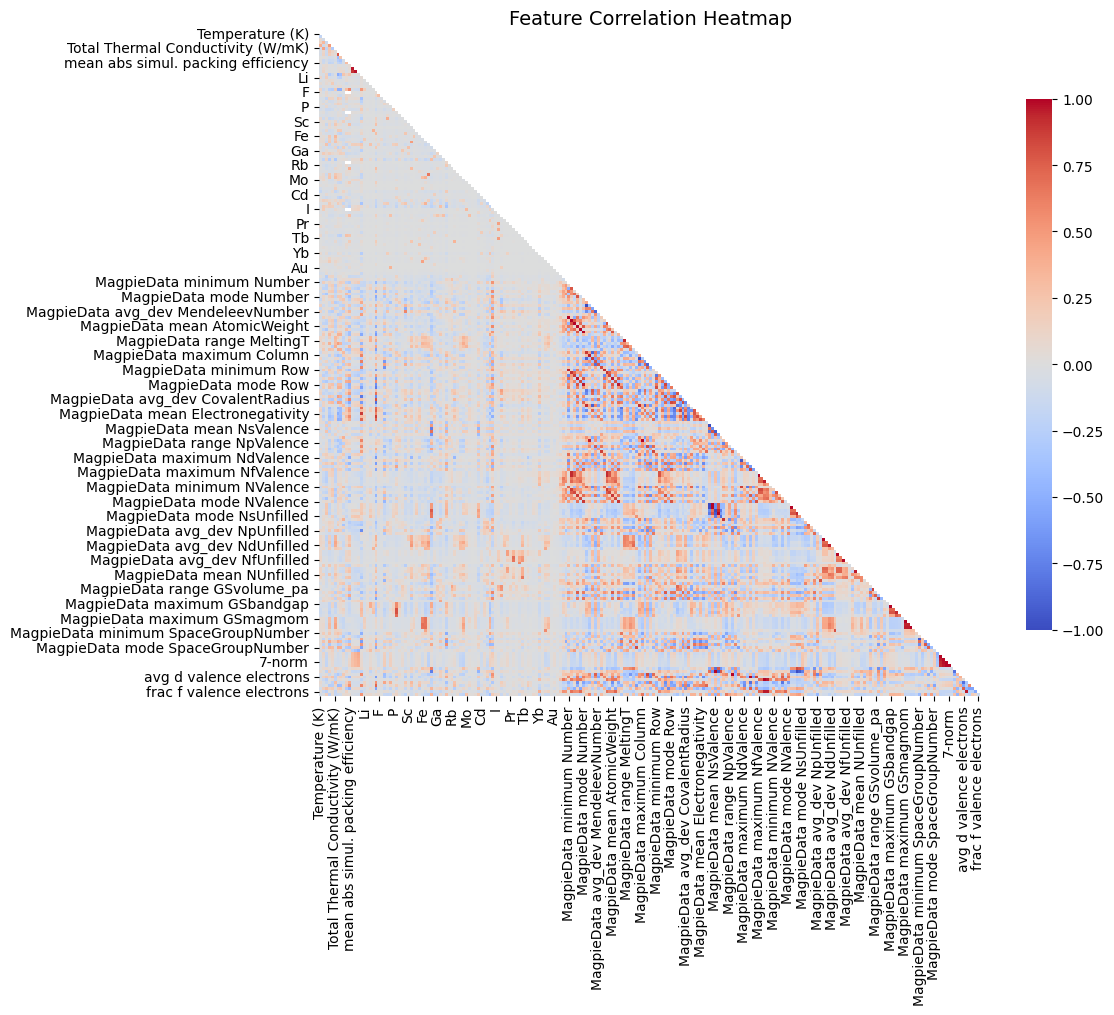

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) compute correlation matrix (numeric columns only)
corr = df_clean.corr(numeric_only=True)

# 2) mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3) plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=False,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


Using columns:
['Electrical Conductivity (S/cm)', 'Seebeck Coefficient (µV/K)', 'Power Factor (µW/cmK²)', 'zT', 'Total Thermal Conductivity (W/mK)']


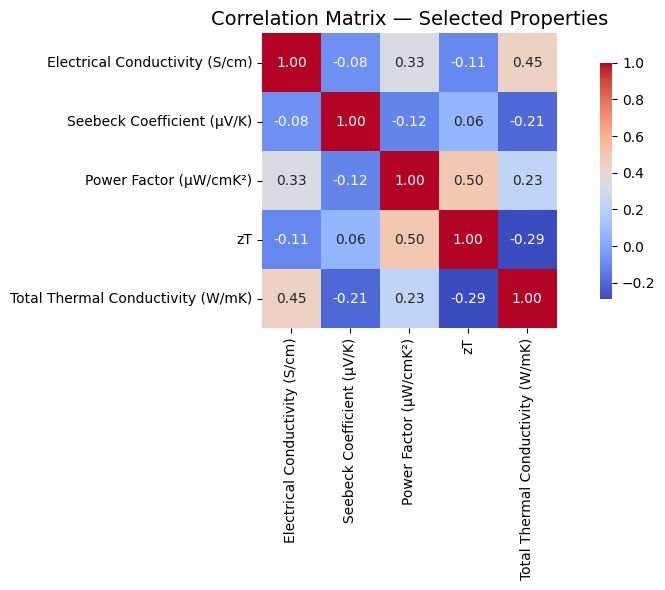

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# columns of interest
cols_of_interest = [
    "Electrical Conductivity (S/cm)",
    "Seebeck Coefficient (µV/K)",
    "Power Factor (µW/cmK²)",
    "zT",
    "Total Thermal Conductivity (W/mK)"]

# keep only those that exist in the dataframe
cols_present = [c for c in cols_of_interest if c in df_clean.columns]

print("Using columns:")
print(cols_present)

# compute correlation
corr = df_clean[cols_present].corr(numeric_only=True)

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

# heatmap plot
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Matrix — Selected Properties", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
df_clean=df_clean.drop(columns=['mean simul. packing efficiency', 'mean abs simul. packing efficiency'])

df_clean=df_clean.drop(columns=['dist from 1 clusters |APE| < 0.010', 'dist from 3 clusters |APE| < 0.010', 'dist from 5 clusters |APE| < 0.010'])


In [30]:
df_clean=df_clean.drop(columns=['Power Factor (µW/cmK²)'])


df_clean.to_csv('CLEANED_DATA.csv')